
# CADERNO DE EXERCICIOS - Analise de Dados com Pandas e Seaborn
 Base de dados: modafina_vendas.csv (loja ficticia de roupas)
# Como usar:
   - Coloque o arquivo modafina_vendas.csv na pasta data.
  - Leia a instrucao de cada celula e escreva seu codigo logo abaixo dela.


In [70]:
# Exercicio 1
# Importe as bibliotecas pandas e seaborn e configure o tema visual dos graficos.
import pandas as pd
import seaborn as sns
import locale

locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
sns.set_theme(style='darkgrid')

In [71]:
# Exercicio 2
# Carregue o arquivo modafina_vendas.csv em um DataFrame
# e mostre as primeiras linhas para conhecer os dados.
df = pd.read_csv(r"data\dataset_aula02_exercicio_modafina.csv", parse_dates=["data_venda"])
df.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [72]:
# Exercicio 3
# Mostre quantas linhas e quantas colunas a base de dados possui.
df.shape

(700, 8)

In [73]:
# Exercicio 4
# Mostre as informacoes gerais da base: o nome das colunas,
# o tipo de cada uma e a quantidade de valores nao nulos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data_venda         700 non-null    datetime64[us]
 1   categoria_produto  700 non-null    str           
 2   tamanho            700 non-null    str           
 3   preco              700 non-null    float64       
 4   quantidade         700 non-null    int64         
 5   estado             700 non-null    str           
 6   forma_pagamento    700 non-null    str           
 7   nota_avaliacao     700 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 55.5 KB


In [74]:
# Exercicio 5
# Crie uma nova coluna chamada faturamento, multiplicando o preco
# pela quantidade de cada venda. Depois, mostre as primeiras linhas.
df_teste = df.copy()
df_teste["faturamento"] = df_teste["preco"] * df_teste["quantidade"]
df_teste.head()


,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [75]:
# Exercicio 6
# Calcule o faturamento total da loja (a soma da coluna faturamento).
# Em seguida, exiba esse valor formatado como moeda brasileira,
# no formato R$ 0.000,00 (exemplo: R$ 232.687,92).
faturamento_total = df_teste["faturamento"].sum()
print(faturamento_total)
faturamento_reais = locale.currency(faturamento_total, grouping=True)
faturamento_formatado = f"R$ {faturamento_total:,.2f}".replace(",","x").replace(".",",").replace("x",".")
print(f"Faturamento formatado: {faturamento_formatado}")
print(f"Faturamento reais: {faturamento_reais}")

232687.91999999998
Faturamento formatado: R$ 232.687,92
Faturamento reais: R$ 232.687,92


In [76]:
# Exercicio 7
# Descubra quantos pedidos existem de cada categoria de produto.
# pedidos = df_teste["categoria_produto"].unique()
# print(pedidos)

#Ascending reorganiza os dados

df_teste["categoria_produto"].value_counts().sort_values(ascending=False)

categoria_produto
Camisetas     191
Calças        153
Vestidos      137
Calçados      118
Acessórios    101
Name: count, dtype: int64

In [77]:
# Exercicio 8
# Descubra quanto cada categoria de produto faturou no total,
# ordenando da que mais faturou para a que menos faturou.
faturamento_por_categoria = df_teste.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=True)

In [78]:
def converter(valor):
    return f"{valor:,.2f}".replace(",","x").replace(".",",").replace("x",".")

faturamento_por_categoria.map(converter)

categoria_produto
Acessórios    17.504,51
Camisetas     31.637,03
Calças        51.954,17
Vestidos      63.743,92
Calçados      67.848,29
Name: faturamento, dtype: str

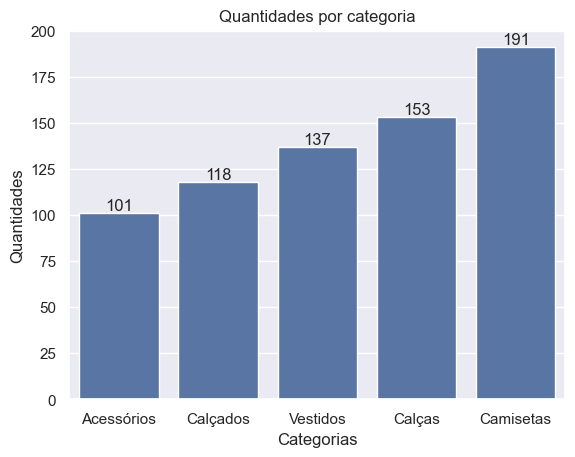

In [79]:
# Exercicio 9
# Crie um grafico que mostre a quantidade de pedidos por categoria de produto.
# Coloque um titulo no grafico e nomes nos eixos.
df_teste["categoria_produto"].value_counts()
grafico = sns.countplot(data=df_teste, x="categoria_produto",order=df_teste["categoria_produto"].value_counts(ascending=True).index)

grafico.bar_label(grafico.containers[0])
grafico.set_title("Quantidades por categoria");
grafico.set_xlabel("Categorias");
grafico.set_ylabel("Quantidades");

C:\Users\FIC.ECFP507D1319372\AppData\Local\Temp\ipykernel_19172\3191088959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.boxplot(data=df_teste,x="categoria_produto",y="preco", palette="viridis")


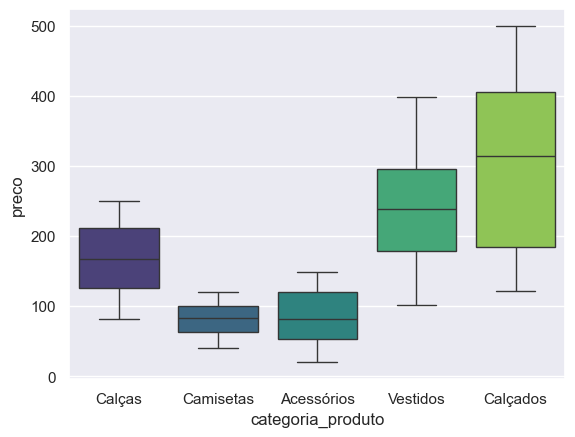

In [80]:
# Exercicio 10
# Crie um grafico que compare a distribuicao do preco entre as
# diferentes categorias de produto. Coloque um titulo no grafico.
grafico = sns.boxplot(data=df_teste,x="categoria_produto",y="preco", palette="viridis")

Text(0, 0.5, 'Quantidade')

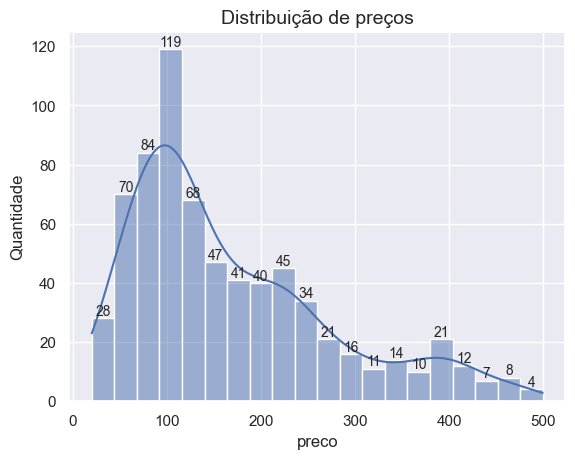

In [81]:
# Exercicio 11
# Crie um grafico que mostre a distribuicao dos precos dos produtos.
# Coloque um titulo no grafico.
grafico = sns.histplot(data=df_teste,x="preco",kde=True, bins=20)
grafico.bar_label(grafico.containers[0], fontsize=10)
grafico.set_title("Distribuição de preços", fontsize=14)
grafico.set_ylabel("Quantidade")